# 1. The facility model

This notebook runs the core of the paper's model for the hypothetical 100 MW (IT) AI campus near Abu Dhabi:

1. it builds hourly inputs for 2025 from the archived ERA5 weather and the public workload traces;
2. it solves a year of business as usual (S0) and of the system-optimal schedule under the synthetic 2030 net-load signal (S2);
3. it computes the firm load reduction $F(d)$: the reduction the campus holds for $d$ hours from the daily net-load peak on 80% of summer days.

Each result is printed next to the number in the paper (`results/numbers.csv`), so the notebook is also a reproducibility check. It runs in under a minute on a laptop CPU.

**Inputs.** The weather archive (`data/weather/`) and the Azure inference trace (`data/azure_llm.csv`) are included. The Alibaba GPU trace is not redistributed: run `python scripts/prep_alibaba_gpu.py` once from `experiments/` to create `data/alibaba_jobs.csv`.

In [1]:
import os, pathlib, sys
if pathlib.Path.cwd().name == "notebooks":
    os.chdir("..")                      # data paths are relative to experiments/
sys.path.insert(0, ".")

import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dcflex.config import Site, Facility, System, Tariffs, Study
from dcflex import data, model, analysis
from dcflex.signal import system_signal
from dcflex.style import PALETTE as C, apply_publication_style
%matplotlib inline
apply_publication_style()
plt.rcParams["figure.dpi"] = 110

# the numbers printed in the paper, written by run_all.py and run_ml.py
paper = pd.read_csv("../results/numbers.csv", index_col="macro", dtype=str)["value"]

def check(name, value):
    """Print a value computed here next to the number printed in the paper, at the paper's precision."""
    printed = paper[name]
    decimals = len(printed.split(".")[1]) if "." in printed else 0
    here = f"{value:.{decimals}f}"
    print(f"{name:26s} here {here:>8s}   paper {printed:>8s}   {'same' if here == printed else 'DIFFERENT'}")

## Inputs

Every parameter is defined, with its source, in `dcflex/config.py` (Appendix A of the paper). Interactive inference is served on arrival. Training and batch work can be deferred, but must be finished within service deadlines of 12 and 24 hours.

In [2]:
site, fac, sysp, tar, st = Site(), Facility(), System(), Tariffs(), Study()
if not pathlib.Path("data/alibaba_jobs.csv").exists():
    raise FileNotFoundError("data/alibaba_jobs.csv is missing: run `python scripts/prep_alibaba_gpu.py` "
                            "from experiments/ once (it downloads the Alibaba GPU trace)")

idx = data.hourly_index(st.year)                                   # 2025, hourly, Gulf time
w = data.fetch_weather(site.lat, site.lon, f"{st.year}-01-01", f"{st.year}-12-31", site.tz,
                       model=st.weather_model)                     # read from data/weather/ (ERA5)
w = w.reindex(idx).interpolate().bfill().ffill()
temp = w["temp"].to_numpy(float)
pv = data.pv_output(w, site.lat, site.lon, fac.pv_mwp, site.tz)    # on-site PV, MW
pv_norm = data.pv_output(w, site.lat, site.lon, 1.0, site.tz)      # per MWp, for the system signal

inf_shape = data.profile_from_csv(idx, "data/azure_llm.csv", "requests")       # interactive inference
def_shape = data.profile_from_csv(idx, "data/alibaba_jobs.csv", "gpu_hours")   # training and batch arrivals
arr, p0 = data.build_arrivals(idx, fac, np.random.default_rng(st.seed + 2), inf_shape, def_shape)
inp = model.inputs(fac, arr, p0, temp, pv)
sig = system_signal(temp, pv_norm, sysp)                           # synthetic 2030 Abu Dhabi net load and price

print(f"IT capacity {fac.it_mw:.0f} MW; on-site PV {fac.pv_mwp:.0f} MWp; chilled-water TES {fac.tes_hours:.0f} h of peak heat; "
      f"battery {fac.bess_mw:.0f} MW / {fac.bess_mwh:.0f} MWh")
print(f"deferrable share of mean IT load: {analysis.deferrable_share_pct(fac):.1f}%")
check("RsurplusHours", sig["surplus"].sum())          # hours with net load <= 0 in the 2030 signal

IT capacity 100 MW; on-site PV 30 MWp; chilled-water TES 4 h of peak heat; battery 25 MW / 50 MWh
deferrable share of mean IT load: 20.0%
RsurplusHours              here      339   paper      339   same


The hot-climate tension behind hypothesis H1: on an average summer day, the hours in which solar power pushes the system's net load down are also the hours in which the outdoor air is hottest, so the chillers are least efficient.

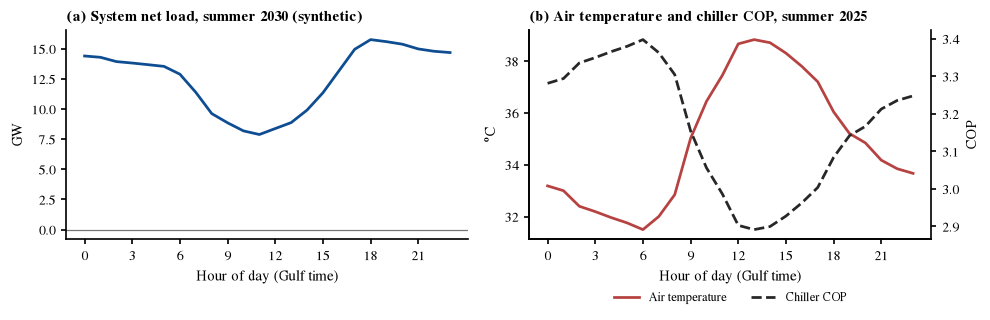

In [3]:
summer = np.isin(idx.month, (6, 7, 8, 9))
hours = np.asarray(idx.hour)[summer]
by_hour = lambda x: pd.Series(np.asarray(x)[summer]).groupby(hours).mean()

fig, (a, b) = plt.subplots(1, 2, figsize=(9, 3.1))
a.plot(by_hour(sig["net"]), color=C["blue_main"])
a.axhline(0, color=C["grey_mid"], lw=0.8)
a.set(xlabel="Hour of day (Gulf time)", ylabel="GW", title="(a) System net load, summer 2030 (synthetic)")
b.plot(by_hour(temp), color=C["red_strong"], label="Air temperature")
b.set(xlabel="Hour of day (Gulf time)", ylabel="°C", title="(b) Air temperature and chiller COP, summer 2025")
b2 = b.twinx()
b2.plot(by_hour(fac.cop(temp)), color=C["ink"], ls="--", label="Chiller COP")
b2.set_ylabel("COP")
b2.spines["right"].set_visible(True)
b.legend(handles=b.get_lines() + b2.get_lines(), loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=8)
for ax in (a, b):
    ax.set_xticks(range(0, 24, 3))
fig.tight_layout()

## A year of operation: S0 and S2

S0 serves work on arrival and leaves storage idle apart from UPS ride-through. S2 minimizes system cost: the marginal energy cost of the synthetic system plus the annualized cost of peaking capacity, spread over the 100 highest net-load hours. The linear program is solved month by month with HiGHS.

In [4]:
t = time.time()
P = analysis.tariff_vectors(idx, tar)
S = {"S0": model.run_monthly(inp, fac, P["addc_commercial"], idx, strategy="bau"),
     "S2": model.run_monthly(inp, fac, sig["price"], idx)}
print(f"solved in {time.time() - t:.1f} s")

sm = {k: analysis.summarize(v, fac, sig, sysp, idx) for k, v in S.items()}
table = pd.DataFrame({k: {"Facility energy (GWh)": s["energy_gwh"], "PUE": s["pue"], "Peak import (MW)": s["peak_mw"],
                          "Import at net-load peak (MW)": s["netpeak_mw"], "Solar-window share (%)": s["solar_share"],
                          "CO2, marginal (kt)": s["co2_marg_kt"]} for k, s in sm.items()}).T
table.round(2)

solved in 1.8 s


,Facility energy (GWh),PUE,Peak import (MW),Import at net-load peak (MW),Solar-window share (%),"CO2, marginal (kt)"
S0,946.29,1.44,150.59,107.23,3.94,316.57
S2,945.26,1.44,189.76,53.19,5.34,310.73


In [5]:
check("RbauEnergyGWh", sm["S0"]["energy_gwh"])
check("RbauPUE", sm["S0"]["pue"])
check("RbauPeakMW", sm["S0"]["peak_mw"])
check("RsolarShareBau", sm["S0"]["solar_share"])
check("RsolarShareSys", sm["S2"]["solar_share"])
check("RnetPeakRedMW", sm["S0"]["netpeak_mw"] - sm["S2"]["netpeak_mw"])
check("RcoolChangeSysPct", 100 * (sm["S2"]["chiller_gwh"] / sm["S0"]["chiller_gwh"] - 1))

RbauEnergyGWh              here    946.3   paper    946.3   same
RbauPUE                    here     1.44   paper     1.44   same
RbauPeakMW                 here    150.6   paper    150.6   same
RsolarShareBau             here      3.9   paper      3.9   same
RsolarShareSys             here      5.3   paper      5.3   same
RnetPeakRedMW              here     54.0   paper     54.0   same
RcoolChangeSysPct          here    -0.77   paper    -0.77   same


Where does S2 move the load? On an average summer day it leaves the evening net-load peak and moves into the early morning, when the air is coolest, rather than into the midday solar window (the thermodynamic penalty of H1).

RsysShiftHour              here        7   paper        7   same


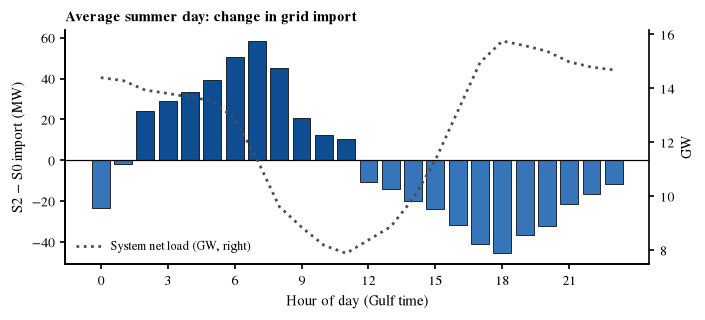

In [6]:
shift = by_hour(S["S2"]["pg"] - S["S0"]["pg"])
fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.bar(shift.index, shift.values, color=[C["blue_main"] if v > 0 else C["blue_secondary"] for v in shift.values],
       edgecolor="black", lw=0.5)
ax.axhline(0, color="black", lw=0.8)
ax.set(xlabel="Hour of day (Gulf time)", ylabel="S2 − S0 import (MW)", title="Average summer day: change in grid import")
ax.set_xticks(range(0, 24, 3))
ax2 = ax.twinx()
ax2.plot(by_hour(sig["net"]), color=C["grey_dark"], ls=":", label="System net load (GW, right)")
ax2.spines["right"].set_visible(True)
ax2.set_ylabel("GW")
ax2.legend(loc="lower left", fontsize=8)
fig.tight_layout()
check("RsysShiftHour", float(np.argmax(shift.values)))

## Firm load reduction $F(d)$

For each of 30 sampled summer days, the model finds the largest reduction below business as usual that the campus can hold for $d$ hours from the daily net-load peak, with every lever and with each lever alone. $F(d)$ is the 20th percentile over the days: a reduction the campus delivers on 80% of days.

In [7]:
rng = np.random.default_rng(st.seed)
days = analysis.sample_days(idx, st, rng, st.flex_days)
t = time.time()
F, per_day = analysis.flex_envelope(inp, fac, sig["net"], days, q=st.reliability_q)
print(f"{len(days)} days, {time.time() - t:.0f} s")
pd.DataFrame(F).T.rename(columns=lambda d: f"F({d}) MW").round(1)

30 days, 9 s


,F(1) MW,F(2) MW,F(4) MW
Compute deferral only,9.3,9.3,9.0
TES only,17.3,17.0,16.7
Battery only,25.0,15.4,7.7
All levers,51.0,42.7,35.7


RshedOneHourMW             here     51.0   paper     51.0   same
RshedTwoHourMW             here     42.7   paper     42.7   same
RshedFourHourMW            here     35.7   paper     35.7   same
RflexComputeMW             here      9.0   paper      9.0   same
RflexTesMW                 here     16.7   paper     16.7   same
RflexBessMW                here      7.7   paper      7.7   same


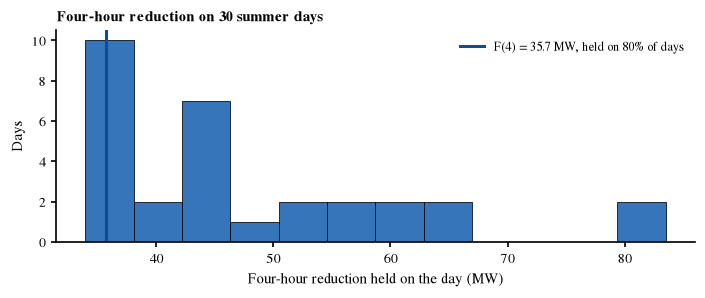

In [8]:
check("RshedOneHourMW", F["All levers"][1])
check("RshedTwoHourMW", F["All levers"][2])
check("RshedFourHourMW", F["All levers"][4])
check("RflexComputeMW", F["Compute deferral only"][4])
check("RflexTesMW", F["TES only"][4])
check("RflexBessMW", F["Battery only"][4])

fig, ax = plt.subplots(figsize=(6.5, 2.8))
ax.hist(per_day["All levers"][4], bins=12, color=C["blue_secondary"], edgecolor="black", lw=0.5)
ax.axvline(F["All levers"][4], color=C["blue_main"], lw=2, label=f"F(4) = {F['All levers'][4]:.1f} MW, held on 80% of days")
ax.legend(fontsize=8, loc="upper right")
ax.set(xlabel="Four-hour reduction held on the day (MW)", ylabel="Days", title="Four-hour reduction on 30 summer days")
fig.tight_layout()

## Next

- `python run_all.py` runs everything else in the paper: the tariff scenarios (S1), the DR contract (S3), the ERCOT benchmark (S4) and the sensitivity analysis, and writes every number, table and figure.
- Notebook 2 tests settlement baselines against manipulation and builds a commit–reveal record.
- Notebook 3 validates the physics-guided baseline on metered buildings.